# In Class Assignment 2026.04.28

## Gaussian Naive Bayes

### Irrigation comp

**Metric:** Balanced accuracy  

**Model:** Gaussian Naive Bayes  

**Data:** Kaggle train data only 

## Imports
Adapted/taken from in class notebook.

In [1]:
# imports 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data and Feature Engineering
Using the same engineered features from previous notebooks since they showed strong importance there. Only using the Kaggle train data as required.

In [2]:
# load training data
train = pd.read_csv('train.csv')

print(train['Irrigation_Need'].value_counts())
print()
print((train['Irrigation_Need'].value_counts() / len(train) * 100).round(1))

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Irrigation_Need
Low       58.7
Medium    37.9
High       3.3
Name: count, dtype: float64


In [3]:
# engineered features from previous notebooks
# group mean from train only (no leakage concern since no test set here)
soil_moisture_by_type = train.groupby('Soil_Type')['Soil_Moisture'].mean()

train['stage_mulch']             = train['Crop_Growth_Stage'].astype(str) + '_' + train['Mulching_Used'].astype(str)
train['stress_index']            = (train['Temperature_C'] + train['Wind_Speed_kmh']) / (train['Soil_Moisture'] + 1)
train['water_deficit']           = train['Temperature_C'] / (train['Rainfall_mm'] / 100 + 1)
train['region_season']           = train['Region'].astype(str) + '_' + train['Season'].astype(str)
train['crop_water_source']       = train['Crop_Type'].astype(str) + '_' + train['Water_Source'].astype(str)
train['sunlight_heat_load']      = train['Sunlight_Hours'] * train['Temperature_C']
train['rainfall_per_sunlight']   = train['Rainfall_mm'] / (train['Sunlight_Hours'] + 1)
train['soil_type_mean_moisture'] = train['Soil_Type'].map(soil_moisture_by_type)
train['moisture_gap']            = train['Soil_Moisture'] - train['soil_type_mean_moisture']

print('features added')

features added


## 2. Prepare Features and Split
Adapted from in-class adult notebook.

In [4]:
# categorical columns including the engineered string interaction features
CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
    'stage_mulch', 'region_season', 'crop_water_source'
]

# encode the target to integers (required for sklearn)
le = LabelEncoder()
y  = le.fit_transform(train['Irrigation_Need'])

# find which index corresponds to the High class
print('Class order:', list(le.classes_))
HIGH_IDX = list(le.classes_).index('High')
print('High class index:', HIGH_IDX)

# all feature columns (drop id and target)
FEAT_COLS = [c for c in train.columns if c not in ['id', 'Irrigation_Need']]
X = train[FEAT_COLS]

# split numeric and categorical columns for the preprocessor
numeric_cols     = [c for c in FEAT_COLS if c not in CAT_COLS]
categorical_cols = [c for c in FEAT_COLS if c in CAT_COLS]

print('\nNumeric features:    ', len(numeric_cols))
print('Categorical features:', len(categorical_cols))

Class order: ['High', 'Low', 'Medium']
High class index: 0

Numeric features:     17
Categorical features: 11


In [5]:
# train/test split, stratified to keep class proportions (from in-class adult notebook)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print('Train rows:', len(X_train))
print('Test rows: ', len(X_test))

Train rows: 504000
Test rows:  126000


## 3. Build Pipeline and Train Model
Pipeline structure adapted directly from in-class adult notebook. The `to_dense` helper and the `ColumnTransformer` + `Pipeline` pattern are from class.

In [6]:
# from in-class adult notebook: GaussianNB needs a dense array, not sparse
def to_dense(x):
    return x.toarray() if hasattr(x, 'toarray') else x

In [7]:
# preprocessor and pipeline structure from in-class adult notebook

# categorical: impute then ordinal encode to integers

# ordinal encoding is used instead of one-hot because one-hot would create
# hundreds of columns and was causing issues overall

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# full pipeline: preprocess, convert to dense, then Naive Bayes
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense',     FunctionTransformer(to_dense)),
    ('model',        GaussianNB())
])

nb_pipeline.fit(X_train, y_train)
print('model trained')

model trained


## 4. Generate Predicted Probabilities

In [8]:
# predict_proba returns one probability per class per row
# shape is (n_samples, n_classes)
probs = nb_pipeline.predict_proba(X_test)

print('Probability matrix shape:', probs.shape)
print('Class order:', list(le.classes_))
print()

# preview first 5 rows
print(pd.DataFrame(probs, columns=le.classes_).head())

Probability matrix shape: (126000, 3)
Class order: ['High', 'Low', 'Medium']

           High       Low    Medium
0  6.156647e-24  0.998610  0.001390
1  2.758359e-05  0.400087  0.599885
2  3.059381e-15  0.966259  0.033741
3  2.727890e-11  0.978387  0.021613
4  1.679168e-18  0.991399  0.008601


## 5. Baseline Predictions: Default Rule
Assign each row the class with the highest predicted probability. 

In [9]:
# argmax picks the column with the highest probability for each row
preds_baseline = probs.argmax(axis=1)

print('Baseline balanced accuracy:', round(balanced_accuracy_score(y_test, preds_baseline), 4))
print()
print('Baseline classification report:')
print(classification_report(y_test, preds_baseline, target_names=le.classes_))

Baseline balanced accuracy: 0.7161

Baseline classification report:
              precision    recall  f1-score   support

        High       0.50      0.66      0.57      4202
         Low       0.79      0.91      0.85     73983
      Medium       0.77      0.58      0.66     47815

    accuracy                           0.78    126000
   macro avg       0.69      0.72      0.69    126000
weighted avg       0.78      0.78      0.77    126000



## 6. Threshold Tuning on the High Class
The helper function below is adapted from the threshold section of the in-class adult notebook, modified here for a multiclass target (not binary).

The approach: start with the default argmax predictions, then override with High wherever P(High) is at or above the threshold. This is the multiclass threshold template shown at the end of the in-class notebook.

In [10]:
# adapted from in-class evaluate_thresholds function, modified for multiclass
def evaluate_thresholds_high(probs, baseline_preds, y_true, class_idx, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.60, 24)
    rows = []
    for t in thresholds:
        # start from default predictions and override where P(High) >= threshold
        preds = baseline_preds.copy()
        preds[probs[:, class_idx] >= t] = class_idx
        rows.append({
            'threshold':         round(t, 3),
            'balanced_accuracy': round(balanced_accuracy_score(y_true, preds), 4),
            'high_predicted':    int((preds == class_idx).sum())
        })
    return pd.DataFrame(rows)


threshold_results = evaluate_thresholds_high(probs, preds_baseline, y_test, HIGH_IDX)

# show top results sorted by balanced accuracy
print('Top thresholds by balanced accuracy:')
print(threshold_results.sort_values('balanced_accuracy', ascending=False).head(10).to_string(index=False))

Top thresholds by balanced accuracy:
 threshold  balanced_accuracy  high_predicted
     0.074             0.7579           12087
     0.098             0.7577           10994
     0.122             0.7571           10230
     0.050             0.7560           13526
     0.146             0.7554            9625
     0.170             0.7538            9143
     0.193             0.7505            8685
     0.217             0.7492            8249
     0.241             0.7461            7894
     0.265             0.7425            7573


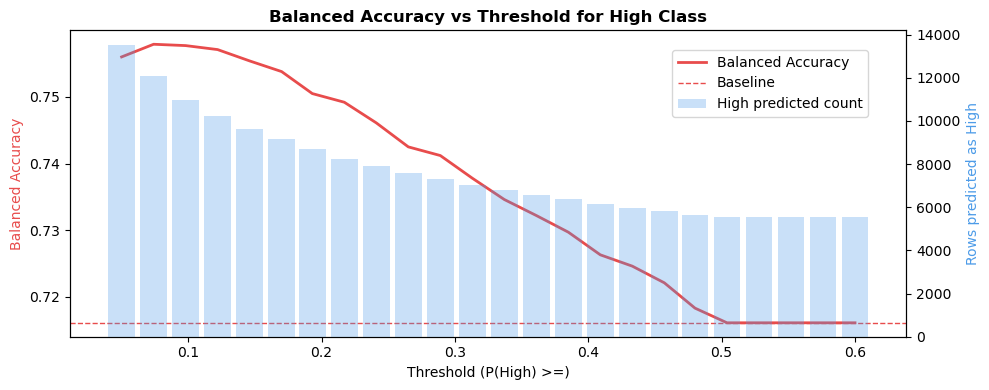

In [11]:
import matplotlib.pyplot as plt

# plot balanced accuracy and number of High predictions across thresholds
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(threshold_results['threshold'], threshold_results['balanced_accuracy'],
         color='#E84C4C', linewidth=2, label='Balanced Accuracy')
ax1.axhline(balanced_accuracy_score(y_test, preds_baseline),
            color='#E84C4C', linestyle='--', linewidth=1, label='Baseline')
ax1.set_xlabel('Threshold (P(High) >=)')
ax1.set_ylabel('Balanced Accuracy', color='#E84C4C')

ax2 = ax1.twinx()
ax2.bar(threshold_results['threshold'], threshold_results['high_predicted'],
        width=0.02, alpha=0.3, color='#4C9BE8', label='High predicted count')
ax2.set_ylabel('Rows predicted as High', color='#4C9BE8')

ax1.set_title('Balanced Accuracy vs Threshold for High Class', fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

## 7. Apply Best Threshold and Compare
Using the multiclass threshold approach shown at the end of the in-class notebook.

In [12]:
# pick threshold with the best balanced accuracy from the sweep
best_row       = threshold_results.loc[threshold_results['balanced_accuracy'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])
print('Best threshold:', BEST_THRESHOLD)

# apply threshold (from in-class multiclass threshold template)
preds_threshold = preds_baseline.copy()
preds_threshold[probs[:, HIGH_IDX] >= BEST_THRESHOLD] = HIGH_IDX

print()
print('Baseline balanced accuracy: ', round(balanced_accuracy_score(y_test, preds_baseline), 4))
print('Threshold balanced accuracy:', round(balanced_accuracy_score(y_test, preds_threshold), 4))
print('Change:                     ', round(balanced_accuracy_score(y_test, preds_threshold) - balanced_accuracy_score(y_test, preds_baseline), 4))

Best threshold: 0.074

Baseline balanced accuracy:  0.7161
Threshold balanced accuracy: 0.7579
Change:                      0.0418


In [13]:
# classification reports to compare baseline vs threshold predictions
# (from in-class multiclass threshold template)
print('Baseline report:')
print(classification_report(y_test, preds_baseline, target_names=le.classes_))

print(f'Threshold ({BEST_THRESHOLD}) report:')
print(classification_report(y_test, preds_threshold, target_names=le.classes_))

Baseline report:
              precision    recall  f1-score   support

        High       0.50      0.66      0.57      4202
         Low       0.79      0.91      0.85     73983
      Medium       0.77      0.58      0.66     47815

    accuracy                           0.78    126000
   macro avg       0.69      0.72      0.69    126000
weighted avg       0.78      0.78      0.77    126000

Threshold (0.074) report:
              precision    recall  f1-score   support

        High       0.31      0.90      0.46      4202
         Low       0.79      0.91      0.85     73983
      Medium       0.77      0.47      0.58     47815

    accuracy                           0.74    126000
   macro avg       0.62      0.76      0.63    126000
weighted avg       0.77      0.74      0.73    126000



## 8. Discussion

**Class selected:** High. It is the rarest class at 3.3% of the data. Balanced accuracy gives each class equal weight regardless of size, so improving High class recall directly moves the score. Also, it represents the highest irrigation need, so it is important just for that reason too.

**Threshold chosen:** The sweep found the best threshold at 0.074. Lowering the threshold to 0.074 forces the model to predict High whenever it has even modest confidence, which recovers more true High rows (12,087 rows predicted as High vs 4,202 actual High rows in the test set).

**How the metric changed:** Balanced accuracy improved from 0.7161 (baseline) to 0.7579 (threshold), a gain of +0.0418. Looking at the classification reports, High class recall increased from 0.66 to 0.90 after the threshold was applied, meaning the model correctly caught more of the actual High cases.

**Tradeoff observed:** High class precision dropped from 0.50 to 0.31 after applying the threshold because more rows got labeled High, including some that were actually Low or Medium. Medium recall dropped from 0.58 to 0.47 since some of those rows got overridden (Low recall stayed the same at 0.91). Catching more true High cases came at the cost of more false positives in that class (which in this case since it isn't life-threatening to catch too many false positives, isn't too bad and might be worth it in my opinion).

**How Naive Bayes compares to existing models:** Naive Bayes is substantially weaker. The competition models (XGBoost, LightGBM, CatBoost, and the stacking ensemble) all scored around 0.965 to 0.970 balanced accuracy on the Kaggle leaderboard. Naive Bayes scores around 0.72 to 0.76 even with threshold tuning, well below those results. Naive Bayes treats every feature as independent given the class, but features like stress_index, water_deficit, and stage_mulch were specifically built to capture joint effects between multiple features.

Overall I found that Naive Bayes is useful as a fast interpretable baseline, but it won't really match other tuned gradient boosting models, especially on this data. I found that this data is a little bit simple though, so maybe this data also just has interactions as more important than another data set would have.